In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import time
import sys
import torch.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from torch.utils.data import Subset
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import pandas as pd
import rasterio as rio
import albumentations as A
from albumentations.pytorch import ToTensorV2


# Now import VGG model and HabitatDataset class
from ImagePreparation import HabitatDataset, prepare_dataset
from VGGModel import ModifiedVGG16Segmentation

# training VGG model
# contains some LLM-generated code

In [15]:
def train_one_epoch(model, loader, optimizer, criterion, device, patch_size, context_width):
    model.train()
    running_loss = 0.0
    pad = (context_width - patch_size) // 2
    for img, mask in loader:
        img = img.to(device)
        mask = mask.to(device).long()
        out = model(img)
        if pad > 0:
            out = out[:, :, pad:pad + patch_size, pad:pad + patch_size]
        loss = criterion(out, mask)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

Computing band statistics for normalization...
Band means: [333.43372 312.73245 366.93146 276.62698 170.5221  256.37604 304.4557
 236.65265]
Band stds: [106.48118  127.770424 205.53941  204.27007  144.62096  251.54451
 359.8682   283.61325 ]

Dataset prepared:
  Mode: patch
  Total samples: 450
  Patch size: 256
  Context width: 320
Computing band statistics for normalization...
Band means: [333.43372 312.73245 366.93146 276.62698 170.5221  256.37604 304.4557
 236.65265]
Band stds: [106.48118  127.770424 205.53941  204.27007  144.62096  251.54451
 359.8682   283.61325 ]
Starting training...

Epoch 01/10 | Train Loss: 1.8919 | Val Loss: 1.8230 | Time: 106.6s
  → New best model saved!
Epoch 02/10 | Train Loss: 1.7077 | Val Loss: 1.6051 | Time: 107.5s
  → New best model saved!
Epoch 03/10 | Train Loss: 1.6264 | Val Loss: 1.7250 | Time: 111.3s
Epoch 04/10 | Train Loss: 1.5078 | Val Loss: 1.5745 | Time: 116.9s
  → New best model saved!
Epoch 05/10 | Train Loss: 1.4370 | Val Loss: 1.3940 | T

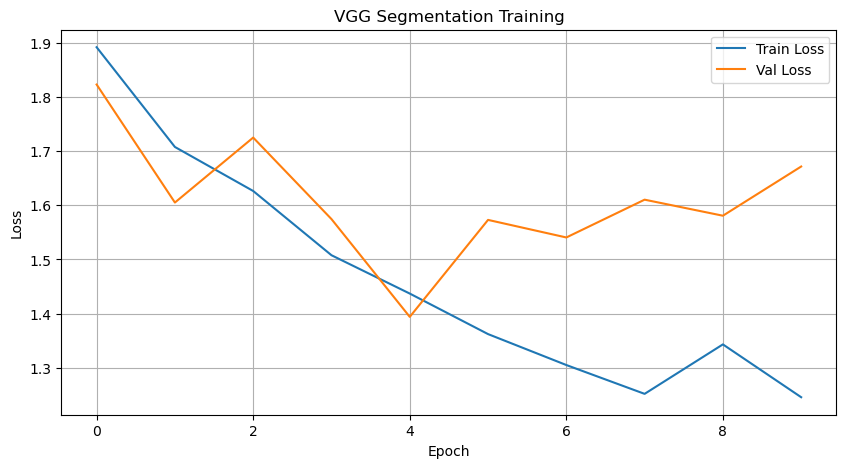

In [ ]:
def validate(model, loader, criterion, device, patch_size, context_width):
    model.eval()
    running_loss = 0.0
    pad = (context_width - patch_size) // 2
    with torch.no_grad():
        for img, mask in loader:
            img = img.to(device)
            mask = mask.to(device).long()
            
            out = model(img)
            if pad > 0:
                out = out[:, :, pad:-pad, pad:-pad]
                
            loss = criterion(out, mask)
            running_loss += loss.item()
            
    return running_loss / len(loader)


if __name__ == "__main__":
    
    IMG_DIR  = r'C:\Users\Peter Chapman\Personal_Research_Projects\benthic-habitat-segmentation-ML\Project 4 Dataset\Project 4 Dataset\raw_labeled_data\images'
    MASK_DIR = r'C:\Users\Peter Chapman\Personal_Research_Projects\benthic-habitat-segmentation-ML\Project 4 Dataset\Project 4 Dataset\raw_labeled_data\annotations'
    

    EPOCHS              = 10          # ← only 10 epochs
    SAMPLES_TRAIN       = 15          # ← only 15 patches per image (was 50)
    SAMPLES_VAL         = 5           # ← only 5 patches per val image (was 10)
    BATCH_SIZE          = 16
    PATCH_SIZE          = 256
    CONTEXT_WIDTH       = 320
    LR                  = 0.001
    
    # Train/val split (by whole images)
    all_images = [f for f in os.listdir(IMG_DIR) if f.endswith('.tif')]
    random.seed(42)
    random.shuffle(all_images)
    split_idx = int(0.8 * len(all_images))
    train_imgs = all_images[:split_idx]
    val_imgs   = all_images[split_idx:]
    
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

    train_tf = A.Compose([
        A.RandomRotate90(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        ToTensorV2()
    ], is_check_shapes=False) 

    val_tf = A.Compose([
        ToTensorV2()
    ], is_check_shapes=False)
    
    # Uses original prepare_dataset
    train_dataset = prepare_dataset(
        img_dir=IMG_DIR,
        mask_dir=MASK_DIR,
        mode='patch',
        patch_size=PATCH_SIZE,
        context_width=CONTEXT_WIDTH,
        samples_per_image=SAMPLES_PER_IMAGE,
        transform=train_tf
    )
    
    val_dataset = HabitatDataset(
        img_dir=IMG_DIR,
        mask_dir=MASK_DIR,
        mode='patch',
        patch_size=PATCH_SIZE,
        context_width=CONTEXT_WIDTH,
        samples_per_image=VAL_SAMPLES_PER_IMG,
        transform=val_tf
    )
    # Replace the image list with only validation images
    val_dataset.images = sorted(val_imgs)
    val_dataset.samples = val_dataset._build_sample_index()   # rebuild index with only val images
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    
    # Model, loss, optimizer
    model = ModifiedVGG16Segmentation(in_channels=8, num_classes=7).to(device)
    class_weights = HabitatDataset.get_class_weights(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    
    # Training loop
    train_losses = []
    val_losses   = []
    best_val_loss = float('inf')
    
    print("Starting training...\n")
    
    for epoch in range(1, EPOCHS + 1):
        start = time.time()
        
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, PATCH_SIZE, CONTEXT_WIDTH)
        val_loss   = validate(model, val_loader, criterion, device, PATCH_SIZE, CONTEXT_WIDTH)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Time: {time.time()-start:.1f}s")
        
        # Checkpoints & best model
        if epoch % 5 == 0:
            torch.save(model.state_dict(), f"vgg_checkpoint_epoch_{epoch}.pth")
            
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "vgg_best_model.pth")
            print("  → New best model saved!")
    
    # Final save
    torch.save(model.state_dict(), "vgg_final_model.pth")
    print("\nTraining finished! Final model saved as 'vgg_final_model.pth'")
    
    # Plot losses
    plt.figure(figsize=(10,5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses,   label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("VGG Segmentation Training")
    plt.grid(True)
    plt.savefig("vgg_training_loss_curve.png")
    plt.show()